# Real Estate Property Price Prediction

This notebook estimates observed NYC property sale prices from property characteristics, location, building classification, and sale timing.

**Business question:** how well can earlier recorded sales support a price estimate for later sales?

**Dataset decision.** Three serious candidates were considered:

| Candidate | Strengths | Limitations | Decision |
|---|---|---|---|
| [NYC Citywide Rolling Calendar Sales](https://data.cityofnewyork.us/dataset/NYC-Citywide-Rolling-Calendar-Sales/usep-8jbt) | First-party public-record sales, location and building attributes, current rolling period, 82,345 raw rows at project creation | Missing square footage and nominal transfers require explicit cleaning; asking/closing-price distinction is not available | **Selected** |
| [King County housing](https://www.kaggle.com/datasets/vallabhadattap/kingcountyhousing) | 21,613 property sales and useful structural features | Older, single-county benchmark commonly mirrored rather than provided through a first-party API | Comparator only |
| [California Housing](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html) | 20,640 observations and easy reproducibility | Aggregated census-block features rather than property-level listings; no property type or building details | Comparator only |

I select NYC for first-party provenance, geographic detail, and property-level features. I do not merge another dataset because no defensible property-level enrichment key is needed here.

## 1. Objectives

I audit and clean the source, explore price patterns, compare a baseline with two regression models, tune the validation winner, and evaluate it once on a later test period.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import requests
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

RANDOM_STATE = 42
DATA_URL = "https://data.cityofnewyork.us/resource/usep-8jbt.csv?$limit=100000"
DATA_PATH = Path("content/nyc_property_sales_monthly_by_borough.csv")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
warnings.filterwarnings("ignore", category=FutureWarning)

## 2. Data loading and source audit

I use the included CSV snapshot. If it is absent, this cell downloads the current rolling extract from the official NYC Open Data API and saves it to the same relative path. The source is time-varying, so the observed date range is printed below.

In [2]:
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
if not DATA_PATH.exists():
    try:
        response = requests.get(DATA_URL, timeout=120)
    except requests.exceptions.SSLError:
        warnings.warn("TLS verification failed; retrying without certificate verification.")
        response = requests.get(DATA_URL, timeout=120, verify=False)
    response.raise_for_status()
    DATA_PATH.write_bytes(response.content)
    print(f"Downloaded {DATA_PATH}")

raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Raw shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"Sale-date range: {raw['sale_date'].min()} to {raw['sale_date'].max()}")
print(f"Exact duplicate rows: {raw.duplicated().sum():,}")
display(raw.head(3))

Raw shape: 82,345 rows x 21 columns
Sale-date range: 2025-09-01T00:00:00.000 to 2026-08-31T00:00:00.000
Exact duplicate rows: 0


,borough,neighborhood,building_class_category,tax_class_at_present,block,lot,ease_ment,building_class_at_present,address,apartment_number,zip_code,residential_units,commercial_units,total_units,land_square_feet,gross_square_feet,year_built,tax_class_at_time_of_sale,building_class_at_time_of,sale_price,sale_date
0,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,372,9,NaN,C7,272 EAST 3 STREET,NaN,10009.0,8.0,1.0,9.0,"2,021",7129.0,1900.0,2,C7,0,2025-12-15T00:00:00.000
1,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,376,41,NaN,C6,"745 EAST 6TH STREET, 1B",NaN,10009.0,28.0,0.0,28.0,"4,542",18254.0,1900.0,2,C4,540000,2025-12-17T00:00:00.000
2,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,377,50,NaN,C2,"275 EAST 7TH STREET, 3",NaN,10009.0,5.0,0.0,5.0,"2,169",6294.0,1900.0,2,C2,1250000,2026-05-27T00:00:00.000


In [3]:
audit = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isna().sum(),
    "missing_pct": (raw.isna().mean() * 100).round(1),
    "unique_values": raw.nunique(dropna=True),
}).sort_values("missing_pct", ascending=False)
display(audit)
display(raw.describe(include="all").T.head(25))

,dtype,missing,missing_pct,unique_values
ease_ment,float64,82345,100.0,0
apartment_number,object,61628,74.8,4723
gross_square_feet,float64,37929,46.1,5860
land_square_feet,object,37929,46.1,5963
commercial_units,float64,34814,42.3,70
residential_units,float64,20250,24.6,167
total_units,float64,17135,20.8,183
year_built,float64,5396,6.6,182
block,int64,0,0.0,11583
borough,int64,0,0.0,5


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
borough,82345.0,NaN,NaN,NaN,2.935187,1.295573,1.0,2.0,3.0,4.0,5.0
neighborhood,82345,252,FLUSHING-NORTH,3633,NaN,NaN,NaN,NaN,NaN,NaN,NaN
building_class_category,82345,44,01 ONE FAMILY DWELLINGS,17304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tax_class_at_present,82345,10,1,36510,NaN,NaN,NaN,NaN,NaN,NaN,NaN
block,82345.0,NaN,NaN,NaN,4159.769798,3551.504484,1.0,1259.0,3233.0,6142.0,16350.0
lot,82345.0,NaN,NaN,NaN,399.62481,660.115692,1.0,23.0,52.0,1005.0,9063.0
ease_ment,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
building_class_at_present,82345,162,R4,13589,NaN,NaN,NaN,NaN,NaN,NaN,NaN
address,82344,80157,N/A COLE STREET,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
apartment_number,20717,4723,2,356,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Cleaning decisions

I remove exact duplicates, invalid dates, non-positive prices, rows without usable gross square footage, and impossible construction years. Missing feature values remain for pipeline imputation. Address, block, lot, and apartment number are identifiers, so I exclude them from modeling. `price_per_sqft` and `log_price` are diagnostic/target-derived fields only; neither is a feature.

In [4]:
def clean_sales(data: pd.DataFrame) -> pd.DataFrame:
    df = data.copy()
    df.columns = [c.strip().lower() for c in df.columns]
    df["sale_date"] = pd.to_datetime(df["sale_date"], errors="coerce")
    for column in ["land_square_feet", "gross_square_feet"]:
        df[column] = pd.to_numeric(df[column].astype(str).str.replace(",", "", regex=False), errors="coerce")

    df = df.drop_duplicates().dropna(subset=["sale_date"])
    df["sale_year"] = df["sale_date"].dt.year
    df["sale_month"] = df["sale_date"].dt.month
    valid = (
        (df["sale_price"] >= 10_000)
        & (df["gross_square_feet"] > 0)
        & (df["year_built"].between(1800, df["sale_year"]))
    )
    df = df.loc[valid].copy()
    df["borough_name"] = df["borough"].map({1: "Manhattan", 2: "Bronx", 3: "Brooklyn", 4: "Queens", 5: "Staten Island"}).fillna("Unknown")
    df["property_age"] = (df["sale_year"] - df["year_built"]).clip(lower=0)
    df["price_per_sqft"] = df["sale_price"] / df["gross_square_feet"]
    df["log_price"] = np.log1p(df["sale_price"])
    return df.sort_values("sale_date").reset_index(drop=True)


sales = clean_sales(raw)
print(f"Modeling rows after documented quality filters: {len(sales):,}")
print(f"Rows retained: {len(sales) / len(raw):.1%}")
print(f"Median sale price: ${sales['sale_price'].median():,.0f}")
display(sales[["sale_date", "borough_name", "building_class_category", "gross_square_feet", "year_built", "sale_price", "price_per_sqft"]].head())

Modeling rows after documented quality filters: 22,272
Rows retained: 27.0%
Median sale price: $988,628


,sale_date,borough_name,building_class_category,gross_square_feet,year_built,sale_price,price_per_sqft
0,2025-09-01,Staten Island,02 TWO FAMILY DWELLINGS,2726.0,2025.0,975000,357.666911
1,2025-09-01,Staten Island,02 TWO FAMILY DWELLINGS,2224.0,1970.0,950000,427.158273
2,2025-09-02,Staten Island,07 RENTALS - WALKUP APARTMENTS,3520.0,1931.0,499000,141.761364
3,2025-09-02,Staten Island,02 TWO FAMILY DWELLINGS,2716.0,2024.0,1354273,498.627761
4,2025-09-02,Brooklyn,02 TWO FAMILY DWELLINGS,1840.0,1930.0,999999,543.477717


## 3. Exploratory data analysis

I check target skew, size-price relationships, borough differences, building categories, and transaction timing.

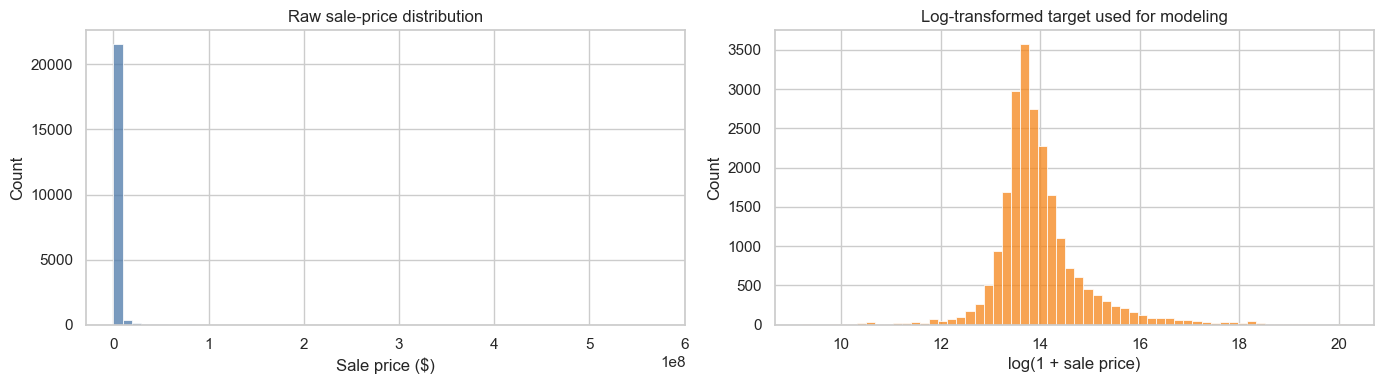

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(sales["sale_price"], bins=60, ax=axes[0], color="#4C78A8")
axes[0].set_title("Raw sale-price distribution")
axes[0].set_xlabel("Sale price ($)")
sns.histplot(sales["log_price"], bins=60, ax=axes[1], color="#F58518")
axes[1].set_title("Log-transformed target used for modeling")
axes[1].set_xlabel("log(1 + sale price)")
plt.tight_layout()
plt.show()

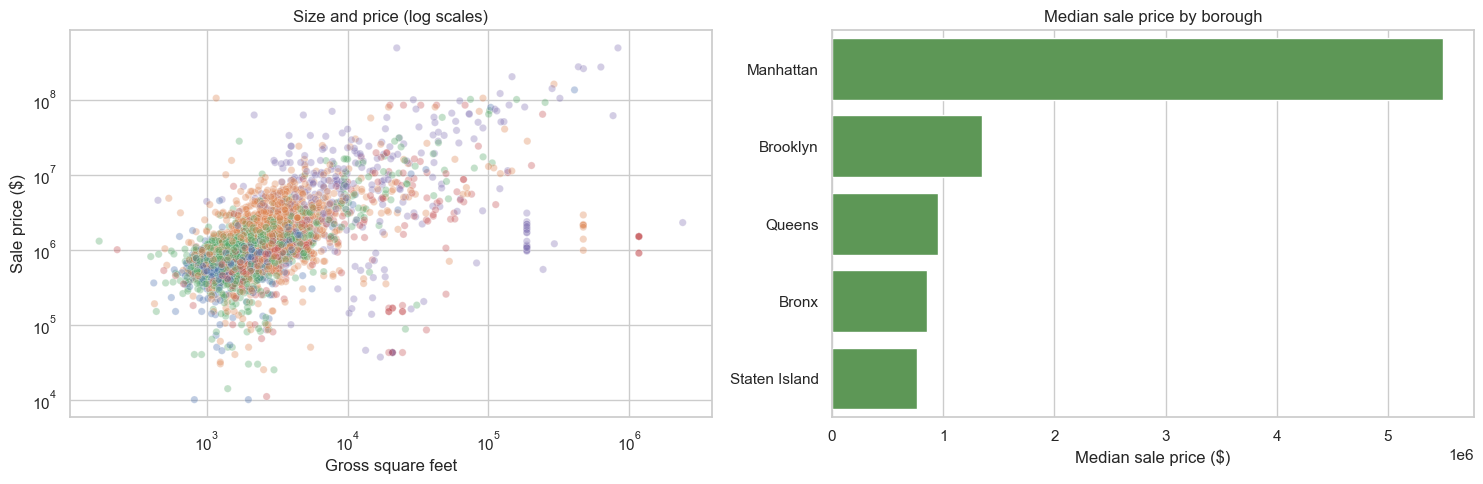

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sample = sales.sample(min(6_000, len(sales)), random_state=RANDOM_STATE)
sns.scatterplot(data=sample, x="gross_square_feet", y="sale_price", hue="borough_name", alpha=0.35, s=28, ax=axes[0], legend=False)
axes[0].set(xscale="log", yscale="log", title="Size and price (log scales)", xlabel="Gross square feet", ylabel="Sale price ($)")
borough_median = sales.groupby("borough_name")["sale_price"].median().sort_values(ascending=False)
sns.barplot(x=borough_median.values, y=borough_median.index, ax=axes[1], color="#54A24B")
axes[1].set(title="Median sale price by borough", xlabel="Median sale price ($)", ylabel="")
plt.tight_layout()
plt.show()

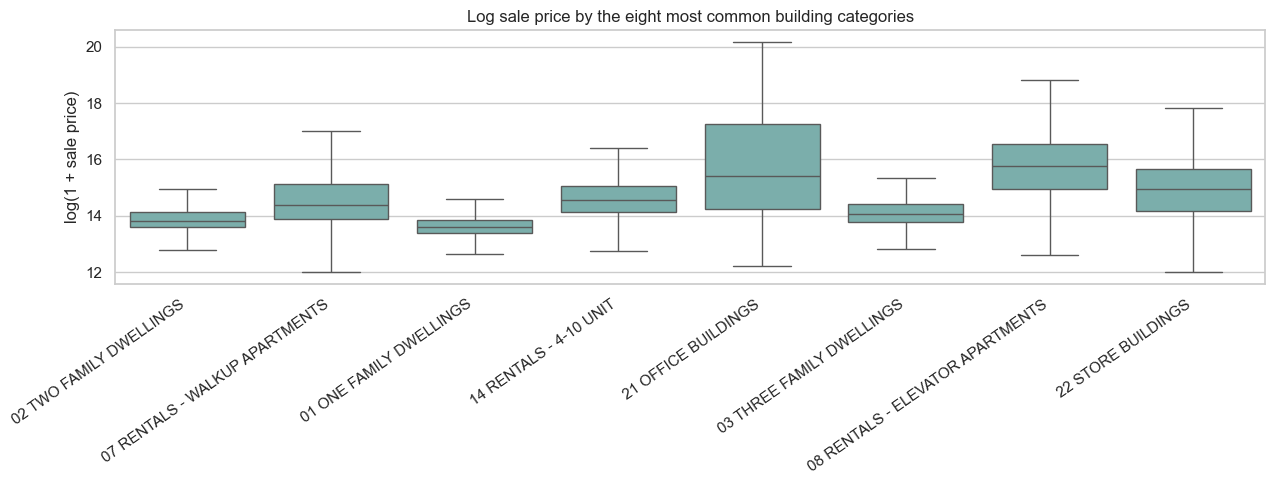

In [7]:
top_categories = sales["building_class_category"].value_counts().head(8).index
plot_data = sales[sales["building_class_category"].isin(top_categories)].copy()
plt.figure(figsize=(13, 5))
sns.boxplot(data=plot_data, x="building_class_category", y="log_price", color="#72B7B2", showfliers=False)
plt.xticks(rotation=35, ha="right")
plt.title("Log sale price by the eight most common building categories")
plt.xlabel("")
plt.ylabel("log(1 + sale price)")
plt.tight_layout()
plt.show()

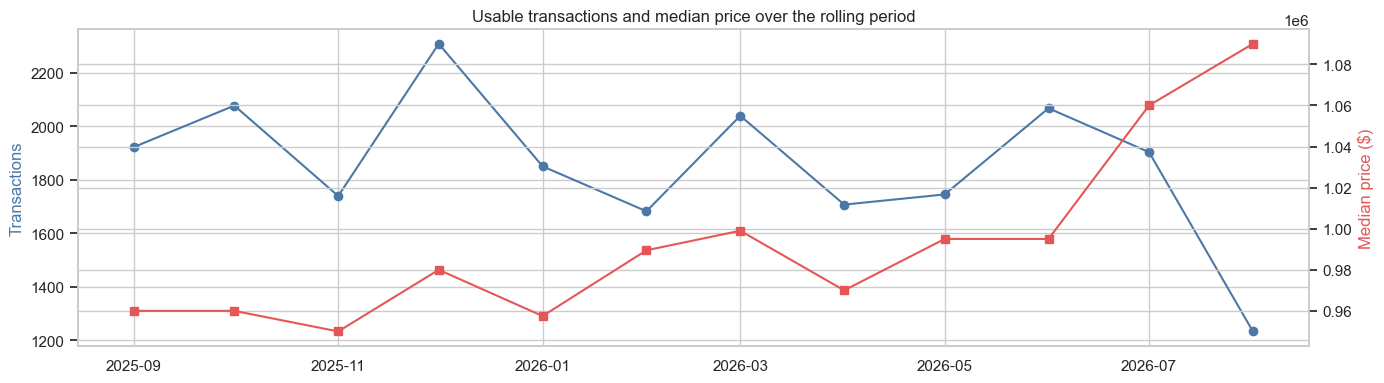

In [8]:
monthly_sales = sales.set_index("sale_date").resample("MS").agg(
    transactions=("sale_price", "size"), median_price=("sale_price", "median")
)
fig, ax1 = plt.subplots(figsize=(14, 4))
ax1.plot(monthly_sales.index, monthly_sales["transactions"], marker="o", color="#4C78A8")
ax1.set_ylabel("Transactions", color="#4C78A8")
ax1.set_title("Usable transactions and median price over the rolling period")
ax2 = ax1.twinx()
ax2.plot(monthly_sales.index, monthly_sales["median_price"], marker="s", color="#E45756")
ax2.set_ylabel("Median price ($)", color="#E45756")
plt.tight_layout()
plt.show()

Prices are strongly right-skewed, so I model `log1p(sale_price)`. Size and location matter, but their within-group variation means a size-only rule is not enough.

## 4. Feature engineering and time-aware split

I use only information available in the sale record: sale year/month, borough, property age, unit counts, area, tax class, building category, neighborhood, and ZIP code. The latest 20% of sales is held out as the final test period.

In [9]:
numeric_features = [
    "gross_square_feet", "land_square_feet", "residential_units", "commercial_units",
    "total_units", "year_built", "property_age", "sale_year", "sale_month",
]
categorical_features = [
    "borough_name", "neighborhood", "building_class_category", "tax_class_at_present", "zip_code",
]
feature_columns = numeric_features + categorical_features
target_column = "sale_price"
target_derived_columns = {"sale_price", "price_per_sqft", "log_price"}
leakage_columns = target_derived_columns.intersection(feature_columns)
assert not leakage_columns, f"Target leakage detected: {leakage_columns}"
print(f"Feature count: {len(feature_columns)}; leakage check passed.")

split_index = int(len(sales) * 0.80)
train_df = sales.iloc[:split_index].copy()
test_df = sales.iloc[split_index:].copy()
X_train = train_df[feature_columns]
y_train = train_df[target_column]
X_test = test_df[feature_columns]
y_test = test_df[target_column]
print(f"Train period: {train_df['sale_date'].min().date()} to {train_df['sale_date'].max().date()} ({len(train_df):,} rows)")
print(f"Test period:  {test_df['sale_date'].min().date()} to {test_df['sale_date'].max().date()} ({len(test_df):,} rows)")

Feature count: 14; leakage check passed.
Train period: 2025-09-01 to 2026-06-12 (17,817 rows)
Test period:  2026-06-12 to 2026-08-31 (4,455 rows)


## 5. Preprocessing and candidate models

Imputation, encoding, and scaling live inside the pipelines. Ridge uses scaled numeric features plus one-hot categories; Gradient Boosting uses imputed numeric features plus ordinal categories. Each transformation is fitted only on its training fold.

In [10]:
numeric_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
numeric_unscaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])
categorical_onehot = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", min_frequency=5)),
])
categorical_ordinal = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

ridge_preprocessor = ColumnTransformer([
    ("num", numeric_scaled, numeric_features),
    ("cat", categorical_onehot, categorical_features),
])
tree_preprocessor = ColumnTransformer([
    ("num", numeric_unscaled, numeric_features),
    ("cat", categorical_onehot, categorical_features),
])
hgb_preprocessor = ColumnTransformer([
    ("num", numeric_unscaled, numeric_features),
    ("cat", categorical_ordinal, categorical_features),
])

def log_target(regressor):
    return TransformedTargetRegressor(regressor=regressor, func=np.log1p, inverse_func=np.expm1)

models = {
    "Ridge": log_target(Pipeline([
        ("preprocess", ridge_preprocessor),
        ("model", Ridge(alpha=10.0)),
    ])),
    "GradientBoosting": log_target(Pipeline([
        ("preprocess", hgb_preprocessor),
        ("model", GradientBoostingRegressor(n_estimators=120, learning_rate=0.06, max_depth=3, min_samples_leaf=3, loss="huber", random_state=RANDOM_STATE)),
    ])),
}

## 6. Validation comparison

I use the earlier part of the training period for fitting and the later part for validation. The median-price baseline is the minimum comparison point. The final test period is still untouched.

In [11]:
inner_split = int(len(X_train) * 0.80)
X_fit, X_valid = X_train.iloc[:inner_split], X_train.iloc[inner_split:]
y_fit, y_valid = y_train.iloc[:inner_split], y_train.iloc[inner_split:]

def regression_metrics(actual, predicted):
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "R2": r2_score(actual, predicted),
    }

comparison_rows = [{"Model": "Median baseline", **regression_metrics(y_valid, np.repeat(y_fit.median(), len(y_valid)))}]
fitted_models = {}
for name, model in models.items():
    model.fit(X_fit, y_fit)
    fitted_models[name] = model
    comparison_rows.append({"Model": name, **regression_metrics(y_valid, model.predict(X_valid))})

comparison = pd.DataFrame(comparison_rows).sort_values("MAE")
display(comparison.style.format({"MAE": "${:,.0f}", "RMSE": "${:,.0f}", "R2": "{:.3f}"}))
best_name = comparison.loc[comparison["Model"].ne("Median baseline"), "Model"].iloc[0]
print(f"Candidate selected for tuning from the validation period: {best_name}")

,Model,MAE,RMSE,R2
2,GradientBoosting,"$1,725,830","$16,515,661",0.170
0,Median baseline,"$2,290,955","$18,240,108",-0.012
1,Ridge,"$24,852,778,268","$1,483,394,280,347",-6695068715.757


Candidate selected for tuning from the validation period: GradientBoosting


## 7. Hyperparameter tuning

I tune the validation winner with a small `RandomizedSearchCV`. `TimeSeriesSplit` keeps each validation fold later than its training fold, and scoring is MAE in original currency units. The final test set is not used.

In [12]:
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
tscv = TimeSeriesSplit(n_splits=3)

if best_name == "Random Forest":
    search_space = {
        "regressor__model__n_estimators": [30, 60, 90],
        "regressor__model__max_features": [0.5, 0.7, 1.0],
        "regressor__model__min_samples_leaf": [1, 2, 4],
    }
elif best_name == "GradientBoosting":
    search_space = {
        "regressor__model__n_estimators": [160, 220, 300],
        "regressor__model__learning_rate": [0.04, 0.08, 0.12],
        "regressor__model__max_depth": [2, 3, 4],
        "regressor__model__min_samples_leaf": [2, 3, 6],
    }
else:
    search_space = {"regressor__model__alpha": [0.1, 1.0, 10.0, 50.0, 100.0]}

search = RandomizedSearchCV(
    estimator=models[best_name], param_distributions=search_space, n_iter=min(4, np.prod([len(v) for v in search_space.values()])),
    scoring=mae_scorer, cv=tscv, random_state=RANDOM_STATE, n_jobs=1, refit=True,
)
search.fit(X_train, y_train)
final_model = search.best_estimator_
print("Best parameters:", search.best_params_)
print(f"Best time-series CV MAE: ${-search.best_score_:,.0f}")

Best parameters: {'regressor__model__n_estimators': 220, 'regressor__model__min_samples_leaf': 3, 'regressor__model__max_depth': 2, 'regressor__model__learning_rate': 0.08}
Best time-series CV MAE: $1,667,380


## 8. Final evaluation on the untouched test period

MAE is the average absolute currency error, RMSE penalizes large misses, and R² compares the model with a mean-price baseline. These metrics do not guarantee an appraisal for an individual property.

In [13]:
test_predictions = final_model.predict(X_test)
final_metrics = regression_metrics(y_test, test_predictions)
final_metrics_table = pd.DataFrame([final_metrics], index=["Final tuned model"])
display(final_metrics_table.style.format({"MAE": "${:,.0f}", "RMSE": "${:,.0f}", "R2": "{:.3f}"}))
print(f"Typical absolute error: about ${final_metrics['MAE']:,.0f} per prediction.")
print(f"The final test period contains {len(y_test):,} sales and was not used during model selection or tuning.")

,MAE,RMSE,R2
Final tuned model,"$1,200,493","$6,696,346",0.407


Typical absolute error: about $1,200,493 per prediction.
The final test period contains 4,455 sales and was not used during model selection or tuning.


In [14]:
error_df = test_df[["sale_date", "borough_name", "sale_price"]].copy()
error_df["prediction"] = test_predictions
error_df["error"] = error_df["prediction"] - error_df["sale_price"]
error_df["absolute_error"] = error_df["error"].abs()
error_df["absolute_pct_error"] = error_df["absolute_error"] / error_df["sale_price"]
error_df["price_band"] = pd.qcut(error_df["sale_price"], q=4, duplicates="drop")

print("Largest absolute errors:")
display(error_df.sort_values("absolute_error", ascending=False).head(10))
print("Error by borough:")
display(error_df.groupby("borough_name").agg(n=("sale_price", "size"), MAE=("absolute_error", "mean"), median_pct_error=("absolute_pct_error", "median")).sort_values("MAE", ascending=False).style.format({"MAE": "${:,.0f}", "median_pct_error": "{:.1%}"}))
print("Error by price band:")
display(error_df.groupby("price_band", observed=True).agg(n=("sale_price", "size"), MAE=("absolute_error", "mean"), RMSE=("error", lambda s: np.sqrt(np.mean(s ** 2)))).style.format({"MAE": "${:,.0f}", "RMSE": "${:,.0f}"}))

Largest absolute errors:


,sale_date,borough_name,sale_price,prediction,error,absolute_error,absolute_pct_error,price_band
21242,2026-08-05,Manhattan,310000000,5.234863e+07,-2.576514e+08,2.576514e+08,0.831133,"(1680056.5, 310000000.0]"
20574,2026-07-27,Manhattan,238190530,9.235215e+07,-1.458384e+08,1.458384e+08,0.612276,"(1680056.5, 310000000.0]"
19929,2026-07-15,Manhattan,122000000,6.314089e+06,-1.156859e+08,1.156859e+08,0.948245,"(1680056.5, 310000000.0]"
19185,2026-07-01,Brooklyn,109000000,1.338579e+07,-9.561421e+07,9.561421e+07,0.877195,"(1680056.5, 310000000.0]"
19305,2026-07-02,Manhattan,100000000,2.196276e+07,-7.803724e+07,7.803724e+07,0.780372,"(1680056.5, 310000000.0]"
20634,2026-07-28,Manhattan,80000000,7.381744e+06,-7.261826e+07,7.261826e+07,0.907728,"(1680056.5, 310000000.0]"
21035,2026-07-31,Manhattan,1600000,6.631457e+07,6.471457e+07,6.471457e+07,40.446607,"(1050000.0, 1680056.5]"
18176,2026-06-17,Manhattan,75000000,1.236533e+07,-6.263467e+07,6.263467e+07,0.835129,"(1680056.5, 310000000.0]"
18137,2026-06-17,Manhattan,75000000,1.269288e+07,-6.230712e+07,6.230712e+07,0.830762,"(1680056.5, 310000000.0]"
20614,2026-07-27,Queens,86878917,3.108376e+07,-5.579516e+07,5.579516e+07,0.642217,"(1680056.5, 310000000.0]"


Error by borough:


,n,MAE,median_pct_error
borough_name,,,
Manhattan,265,"$9,395,447",45.4%
Brooklyn,1472,"$1,260,011",26.0%
Bronx,536,"$515,811",18.6%
Queens,1755,"$367,259",16.6%
Staten Island,427,"$193,566",15.6%


Error by price band:


,n,MAE,RMSE
price_band,,,
"(9999.999, 770000.0]",1117,"$359,797","$1,677,023"
"(770000.0, 1050000.0]",1118,"$172,962","$315,001"
"(1050000.0, 1680056.5]",1106,"$388,484","$2,390,936"
"(1680056.5, 310000000.0]",1114,"$3,880,851","$13,066,325"


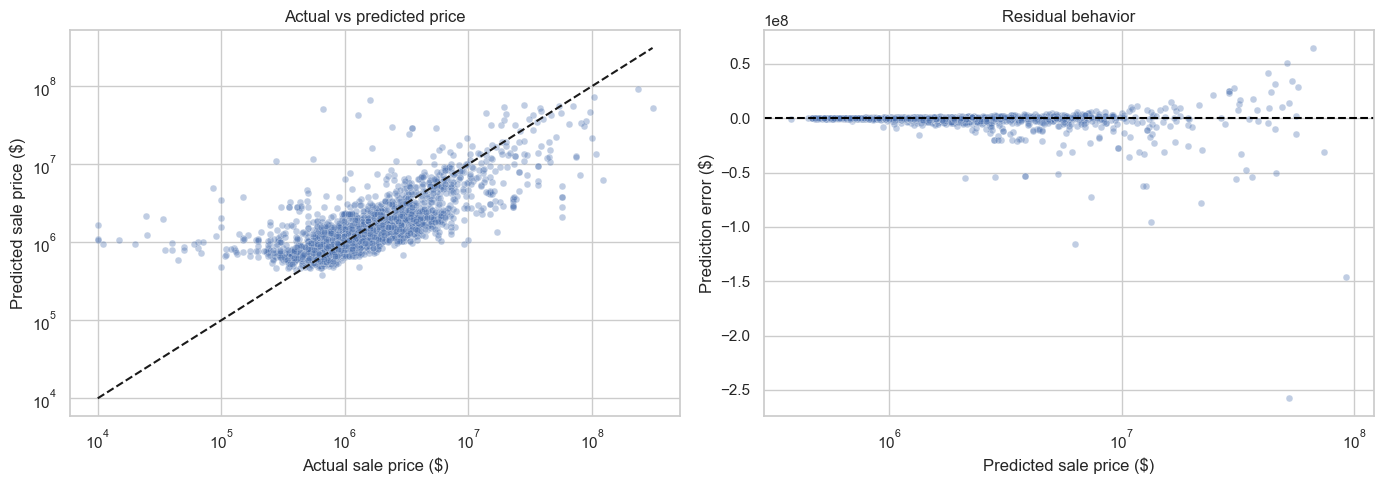

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=y_test, y=test_predictions, alpha=0.35, s=24, ax=axes[0])
limits = [min(y_test.min(), test_predictions.min()), max(y_test.max(), test_predictions.max())]
axes[0].plot(limits, limits, "k--")
axes[0].set(xscale="log", yscale="log", title="Actual vs predicted price", xlabel="Actual sale price ($)", ylabel="Predicted sale price ($)")
sns.scatterplot(x=test_predictions, y=error_df["error"], alpha=0.35, s=24, ax=axes[1])
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set(xscale="log", title="Residual behavior", xlabel="Predicted sale price ($)", ylabel="Prediction error ($)")
plt.tight_layout()
plt.show()

## 9. Model interpretability

I shuffle one original feature at a time and measure the change in test MAE. This is predictive importance, not causality; correlated features can share or dilute the signal.

,feature,mae_increase
4,total_units,"$8,484"
7,sale_year,$-0
8,sale_month,$-0
3,commercial_units,$-214
12,tax_class_at_present,$-811
5,year_built,"$-1,208"
9,borough_name,"$-4,315"
6,property_age,"$-7,574"
10,neighborhood,"$-23,101"
11,building_class_category,"$-33,218"


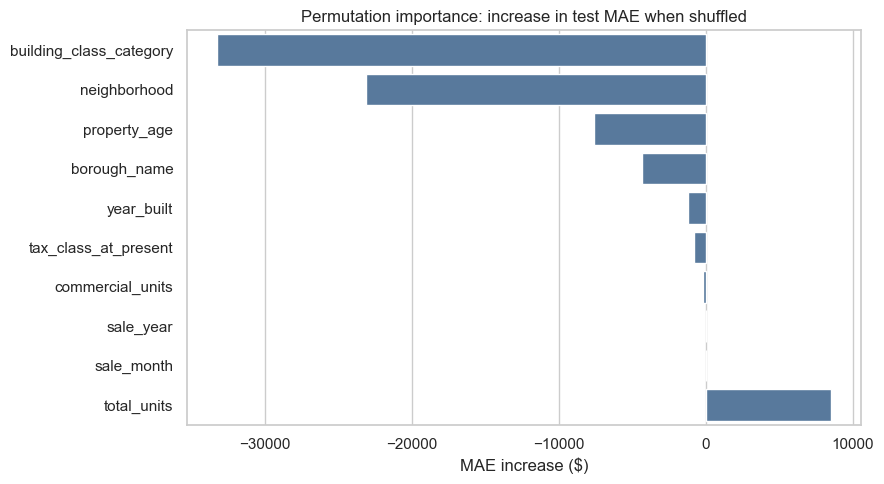

In [16]:
importance_sample = X_test.sample(min(2_000, len(X_test)), random_state=RANDOM_STATE)
importance_target = y_test.loc[importance_sample.index]
permutation = permutation_importance(
    final_model, importance_sample, importance_target, scoring=mae_scorer, n_repeats=5, random_state=RANDOM_STATE, n_jobs=1
)
importance = pd.DataFrame({"feature": feature_columns, "mae_increase": -permutation.importances_mean}).sort_values("mae_increase", ascending=False)
display(importance.head(12).style.format({"mae_increase": "${:,.0f}"}))
plt.figure(figsize=(9, 5))
top_importance = importance.head(10).sort_values("mae_increase")
sns.barplot(data=top_importance, x="mae_increase", y="feature", color="#4C78A8")
plt.title("Permutation importance: increase in test MAE when shuffled")
plt.xlabel("MAE increase ($)")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 10. Business insights, limitations, and conclusion

**Business interpretation.** In the completed run, `total_units` produced the largest positive test-MAE increase under permutation; most other feature-level changes were small or negative on the sampled test set. That is predictive importance in this extract, not a causal claim. The large high-value misses show that the available fields do not fully describe luxury, portfolio, or commercial transactions. The model can support inventory triage, comparable-property screening, and analyst review of potentially unusual prices; it should not replace an appraisal or inspection.

**Limitations.** The source is NYC-specific and represents recorded sale prices in a rolling period, not asking prices or a nationally representative market. Public records contain missing fields, nominal/non-market transfers, heterogeneous property types, and possible recording errors. The time window is short for learning full market cycles. Important variables such as renovation quality, floor, view, condition, financing, and exact unit-level attributes are absent or incomplete. The temporal test estimates performance on later sales from this source period; it does not guarantee future-market performance.

**Conclusion.** This is a supervised regression workflow with documented data selection, explicit quality filters, target-safe features, time-aware validation, pipeline-contained preprocessing, modest tuning, final holdout evaluation, error analysis, and model-agnostic interpretability. Future improvements would include a longer historical extract, validated unit-level characteristics, inflation/market-index features available at prediction time, and geographically grouped validation to test transfer to unseen areas.